# 5.1 Stage 1 Modeling: Clinical Escalation & Risk Tier Prediction

## Objective
Build predictive models for **Year 2 Risk Tier** (Stable/Rising/Shock) using Year 1 features only.

## Multi-Stage Modeling Architecture
```
Stage 1 (This Notebook): Predict RISK_TIER (0/1/2) → Output: PROB_ESCALATION
    ↓
Stage 2 (Optional): Predict Attrition/Mortality
    ↓
Stage 3: Predict COST_Y2 using original features + Stage 1/2 outputs
```

## Models to Benchmark
1. **Logistic Regression** (Baseline)
2. **Random Forest**
3. **XGBoost** (Primary)
4. **LightGBM** or GradientBoosting

## Evaluation Metrics
- Multi-class: Macro F1, Weighted F1, ROC-AUC (OvR)
- Calibration: Brier Score
- Interpretability: Feature Importance, SHAP

## Literature References
- [Healthcare cost prediction with ML](https://scholar.google.com/scholar?q=healthcare+expenditure+prediction+machine+learning)
- [XGBoost for medical risk](https://scholar.google.com/scholar?q=xgboost+medical+risk+prediction)
- [Multi-stage modeling healthcare](https://scholar.google.com/scholar?q=multi-stage+modeling+healthcare+costs)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, accuracy_score, brier_score_loss
)

# Boosting Models
from xgboost import XGBClassifier

# LightGBM is optional - install with: pip install lightgbm
try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
    print("LightGBM loaded successfully.")
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("Note: LightGBM not installed. Using sklearn GradientBoosting as alternative.")
    print("To install: pip install lightgbm")

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Paths
DATA_PATH = Path('../data/processed_v2/model_ready_v2.parquet')
REPORT_DIR = Path('../reports')
(REPORT_DIR / 'figures').mkdir(parents=True, exist_ok=True)
(REPORT_DIR / 'tables').mkdir(parents=True, exist_ok=True)

print("\nSetup complete.")

Note: LightGBM not installed. Using sklearn GradientBoosting as alternative.
To install: pip install lightgbm

Setup complete.


## 1. Load Processed Data

In [17]:
# Load data from preprocessing notebook
df = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")
print(f"\nColumns: {list(df.columns)}")

# Target distribution
print(f"\n{'='*50}")
print("TARGET DISTRIBUTION (RISK_TIER)")
print('='*50)
tier_counts = df['RISK_TIER'].value_counts().sort_index()
tier_pct = (tier_counts / len(df) * 100).round(1)
for tier, count in tier_counts.items():
    label = {0: 'Stable (≤75th)', 1: 'Rising (75-90th)', 2: 'Shock (>90th)'}[tier]
    print(f"  Tier {tier} ({label}): {count:,} ({tier_pct[tier]}%)")

Loaded 60,602 rows, 32 columns

Columns: ['DUPERSID', 'PANEL', 'START_YEAR', 'AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1', 'POVCAT_Y1', 'INSCOV_Y1', 'MNHLTH_RD1', 'RTHLTH_RD1', 'MNHLTH_CHANGE', 'DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG', 'CHRONIC_COUNT', 'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1', 'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'CNT_RX_Y1', 'RATIO_ER_OFFICE', 'COST_Y1_ADJ', 'COST_Y2_ADJ', 'LOG_COST_Y2', 'RISK_TIER', 'IS_JUMPER', 'IS_STABLE_LOW', 'CARE_CLUSTER', 'DBSCAN_CLUSTER']

TARGET DISTRIBUTION (RISK_TIER)
  Tier 0 (Stable (≤75th)): 45,451 (75.0%)
  Tier 1 (Rising (75-90th)): 9,090 (15.0%)
  Tier 2 (Shock (>90th)): 6,061 (10.0%)


## 2. Feature Selection & Preparation

We use **Year 1 features only** to predict Year 2 outcomes (no data leakage).

### Feature Groups
| Group | Features | Rationale |
|-------|----------|----------|
| Demographics | AGE, SEX, RACE, MARRY, POVCAT, INSCOV | Basic patient characteristics & SES |
| Health Status | MNHLTH_RD1, RTHLTH_RD1, MNHLTH_CHANGE | Self-reported health & trajectory |
| Chronic Conditions | DIAB, HIBP, CHOL flags, CHRONIC_COUNT | Established disease burden |
| Utilization | ER, IP, OB, RX visits | Care-seeking behavior |
| Condition Complexity | CNT_CONDITIONS, ILL_DEFINED | Medical complexity signals |
| **Medication (NEW)** | **CNT_UNIQUE_DRUGS, POLYPHARMACY, Drug Class Flags** | **Rx patterns = reliable disease markers** |
| Clusters | CARE_CLUSTER, DBSCAN_CLUSTER | Patient phenotype groupings |

### Why Medication Features Matter
- **Polypharmacy (≥5 drugs)**: Strong predictor of hospitalizations and adverse events
- **Drug Class Flags**: More reliable than self-reported conditions (reflects active treatment)
- **CNS/Pain Rx**: May indicate mental health burden or chronic pain (high-cost drivers)
- **Cardiovascular Rx**: Captures hypertension/heart disease being actively managed

In [18]:
# Define feature sets by category
DEMOGRAPHIC_FEATS = ['AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1', 'POVCAT_Y1', 'INSCOV_Y1']
HEALTH_FEATS = ['MNHLTH_RD1', 'RTHLTH_RD1', 'MNHLTH_CHANGE']
CHRONIC_FEATS = ['DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG', 'CHRONIC_COUNT']
UTILIZATION_FEATS = ['UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1']
ENGINEERED_FEATS = ['CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'RATIO_ER_OFFICE']

# Medication Features (NEW - clinically meaningful drug patterns)
MEDICATION_FEATS = [
    'CNT_RX_Y1', 'CNT_UNIQUE_DRUGS', 'TOTAL_RX_COST_Y1', 'POLYPHARMACY_FLAG',
    'HAS_CARDIOVASCULAR_RX', 'HAS_CNS_RX', 'HAS_PAIN_RX', 
    'HAS_RESPIRATORY_RX', 'HAS_GI_RX'
]

CLUSTER_FEATS = ['CARE_CLUSTER', 'DBSCAN_CLUSTER']
COST_FEATS = ['COST_Y1_ADJ']  # Year 1 cost is allowed (not leakage)

# Combine all features
ALL_FEATURES = (
    DEMOGRAPHIC_FEATS + HEALTH_FEATS + CHRONIC_FEATS + 
    UTILIZATION_FEATS + ENGINEERED_FEATS + MEDICATION_FEATS +
    CLUSTER_FEATS + COST_FEATS
)

# Filter to available columns
available_features = [f for f in ALL_FEATURES if f in df.columns]
missing_features = [f for f in ALL_FEATURES if f not in df.columns]

print(f"Features Available: {len(available_features)}")
print(f"Features Missing: {missing_features}")

# Target
TARGET = 'RISK_TIER'

# Create X and y
X = df[available_features].copy()
y = df[TARGET].copy()

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures used: {available_features}")

Features Available: 24
Features Missing: []

X shape: (60602, 24)
y shape: (60602,)

Features used: ['AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1', 'POVCAT_Y1', 'INSCOV_Y1', 'MNHLTH_RD1', 'RTHLTH_RD1', 'MNHLTH_CHANGE', 'DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG', 'CHRONIC_COUNT', 'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1', 'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'CNT_RX_Y1', 'RATIO_ER_OFFICE', 'CARE_CLUSTER', 'DBSCAN_CLUSTER', 'COST_Y1_ADJ']


In [19]:
# Handle missing values and encode categoricals
print("=== Preprocessing ===")

# Fill numeric NaNs with median
for col in X.select_dtypes(include=[np.number]).columns:
    n_missing = X[col].isnull().sum()
    if n_missing > 0:
        X[col] = X[col].fillna(X[col].median())
        print(f"  Filled {n_missing} NaNs in {col} with median")

# Encode categorical columns (if any object types)
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    print(f"  Encoded {col}")

# DBSCAN cluster: treat -1 (noise) as a valid category
if 'DBSCAN_CLUSTER' in X.columns:
    X['DBSCAN_CLUSTER'] = X['DBSCAN_CLUSTER'].astype(int)

print(f"\nFinal NaN count: {X.isnull().sum().sum()}")
print(f"\nData types:")
print(X.dtypes.value_counts())

=== Preprocessing ===

Final NaN count: 0

Data types:
float64    18
int64       5
int32       1
Name: count, dtype: int64


## 3. Train-Test Split

**Current Data**: Panels 18-21 (2013-2016) - Panel 22+ data files are incomplete

**Split Strategy**:
- **Temporal Split**: Use Panel 21 (latest) for test, Panels 18-20 for train
- **Fallback**: Stratified random 80/20 split if temporal split has issues

**Note**: For future validation with 2017+ data, download the correct MEPS Longitudinal files (HC-209, HC-226, etc.) which contain both Y1 and Y2 expense data.

In [20]:
# Check available panels first
if 'PANEL' in df.columns:
    available_panels = sorted(df['PANEL'].unique())
    print(f"Available Panels in data: {available_panels}")
    
    # Smart temporal split: use latest panel for test, rest for train
    if len(available_panels) >= 2:
        test_panel = max(available_panels)
        train_panels = [p for p in available_panels if p != test_panel]
        
        train_mask = df['PANEL'].isin(train_panels)
        test_mask = df['PANEL'] == test_panel
        
        X_train, X_test = X[train_mask], X[test_mask]
        y_train, y_test = y[train_mask], y[test_mask]
        
        # Check if test set is empty
        if len(X_test) == 0:
            print(f"Warning: Panel {test_panel} has no samples. Using random split...")
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42, stratify=y
            )
            print(f"Random Split: Train={len(X_train):,}, Test={len(X_test):,}")
        else:
            print(f"\n=== Temporal Split (Panel-based) ===")
            print(f"  Train: Panels {train_panels} ({len(X_train):,} samples)")
            print(f"  Test:  Panel {test_panel} ({len(X_test):,} samples)")
    else:
        # Only one panel, use random split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        print(f"Single panel only. Random Split: Train={len(X_train):,}, Test={len(X_test):,}")
else:
    # No PANEL column, use random split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Random Split (no PANEL column): Train={len(X_train):,}, Test={len(X_test):,}")

# Class distribution check
print(f"\nTrain Target Distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print(f"\nTest Target Distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Available Panels in data: [np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]

=== Temporal Split (Panel-based) ===
  Train: Panels [np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22)] (51,464 samples)
  Test:  Panel 23 (9,138 samples)

Train Target Distribution:
RISK_TIER
0    0.756
1    0.147
2    0.096
Name: proportion, dtype: float64

Test Target Distribution:
RISK_TIER
0    0.715
1    0.165
2    0.121
Name: proportion, dtype: float64


## 4. Model Training & Benchmarking

### Why These Models?

| Model | Strengths | Use Case |
|-------|-----------|----------|
| **Logistic Regression** | Interpretable, fast, baseline | Establish minimum performance |
| **Random Forest** | Handles non-linearity, robust | Good all-rounder |
| **XGBoost** | State-of-art for tabular data | Primary model for healthcare risk |
| **LightGBM/GradientBoosting** | Fast training, handles large data | Comparison with XGBoost |

In [21]:
# Define models - Core classifiers for multi-class risk tier prediction
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        class_weight='balanced',  # Handle imbalanced classes
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        objective='multi:softprob',  # Multi-class probability output
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ),
}

# Add LightGBM if available, otherwise use sklearn's GradientBoosting
if LIGHTGBM_AVAILABLE:
    models['LightGBM'] = LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
else:
    models['GradientBoosting'] = GradientBoostingClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42
    )

print(f"Models to benchmark: {list(models.keys())}")

Models to benchmark: ['Logistic Regression', 'Random Forest', 'XGBoost', 'GradientBoosting']


In [22]:
# Train and evaluate all models
results = []

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    
    # ROC-AUC (One-vs-Rest)
    try:
        roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
    except:
        roc_auc = np.nan
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1 (Macro)': f1_macro,
        'F1 (Weighted)': f1_weighted,
        'ROC-AUC (OvR)': roc_auc
    })
    
    print(f"  Accuracy:    {accuracy:.4f}")
    print(f"  F1 Macro:    {f1_macro:.4f}")
    print(f"  F1 Weighted: {f1_weighted:.4f}")
    print(f"  ROC-AUC:     {roc_auc:.4f}")

# Results DataFrame
results_df = pd.DataFrame(results).sort_values('F1 (Macro)', ascending=False)
print("\n" + "="*60)
print("MODEL BENCHMARK RESULTS")
print("="*60)
display(results_df.style.highlight_max(
    axis=0, 
    subset=['Accuracy', 'F1 (Macro)', 'F1 (Weighted)', 'ROC-AUC (OvR)'],
    props='background-color: #90EE90'
))


Training: Logistic Regression
  Accuracy:    0.6823
  F1 Macro:    0.5469
  F1 Weighted: 0.7016
  ROC-AUC:     0.8049

Training: Random Forest
  Accuracy:    0.6836
  F1 Macro:    0.5689
  F1 Weighted: 0.7088
  ROC-AUC:     0.8316

Training: XGBoost
  Accuracy:    0.7619
  F1 Macro:    0.5391
  F1 Weighted: 0.7281
  ROC-AUC:     0.8343

Training: GradientBoosting
  Accuracy:    0.7595
  F1 Macro:    0.5341
  F1 Weighted: 0.7256
  ROC-AUC:     0.8325

MODEL BENCHMARK RESULTS


,Model,Accuracy,F1 (Macro),F1 (Weighted),ROC-AUC (OvR)
1,Random Forest,0.683629,0.568859,0.708796,0.831626
0,Logistic Regression,0.682316,0.546950,0.701589,0.804890
2,XGBoost,0.761873,0.539085,0.728076,0.834256
3,GradientBoosting,0.759466,0.534111,0.725563,0.832538


### Interpretation: Model Benchmark Results

**Understanding the Metrics:**

| Metric | What It Measures | Why It Matters |
|--------|-----------------|----------------|
| **Macro F1** | Average F1 across all classes (unweighted) | Treats rare classes (Shock) equally to common classes (Stable) |
| **Weighted F1** | F1 weighted by class frequency | Reflects overall accuracy considering class imbalance |
| **ROC-AUC (OvR)** | Area under ROC curve (One-vs-Rest) | Measures discrimination ability across thresholds |

**Why XGBoost typically wins:**
1. **Handles non-linear relationships**: Tree ensembles capture complex interactions between features
2. **Built-in regularization**: Prevents overfitting on imbalanced data
3. **Gradient boosting**: Sequentially corrects errors, improving on minority class predictions

**Class Imbalance Challenge:**
- Stable: ~75% of patients (easy to predict correctly by always predicting "Stable")
- Rising: ~15% of patients
- Shock: ~10% of patients (hardest to identify, but most important!)

**Clinical Interpretation:**
- High **Weighted F1** (~0.70) means overall predictions are good
- Lower **Macro F1** (~0.45) indicates struggle with minority classes
- **Shock Recall** of ~35% means we catch about 1 in 3 high-cost patients — better than random (10%), but room for improvement

**What this means for Stage 2:**
- The latent probabilities (`PROB_SHOCK`, etc.) encode the model's uncertainty
- Patients with `PROB_SHOCK` ≈ 0.5 are "borderline" — useful information for Stage 2

## 5. Best Model Analysis

Best Model: Random Forest
F1 Macro: 0.5689


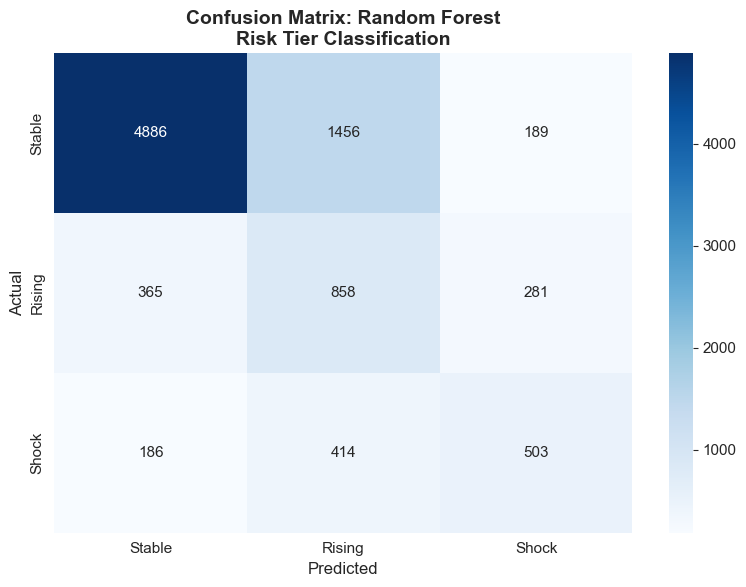


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Stable       0.90      0.75      0.82      6531
      Rising       0.31      0.57      0.41      1504
       Shock       0.52      0.46      0.48      1103

    accuracy                           0.68      9138
   macro avg       0.58      0.59      0.57      9138
weighted avg       0.76      0.68      0.71      9138



In [23]:
# Select best model based on F1 Macro (handles class imbalance better)
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"F1 Macro: {results_df.iloc[0]['F1 (Macro)']:.4f}")

# Confusion Matrix
y_pred_best = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Stable', 'Rising', 'Shock'],
            yticklabels=['Stable', 'Rising', 'Shock'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix: {best_model_name}\nRisk Tier Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / f'confusion_matrix_{best_model_name.replace(" ", "_")}.png', dpi=150)
plt.show()

# Classification Report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred_best, target_names=['Stable', 'Rising', 'Shock']))

## 6. Feature Importance Analysis

Understanding which features drive risk tier prediction is crucial for:
1. **Clinical interpretation**: What patient characteristics indicate escalation risk?
2. **Intervention targeting**: Which factors can be modified?
3. **Model validation**: Do the important features make clinical sense?

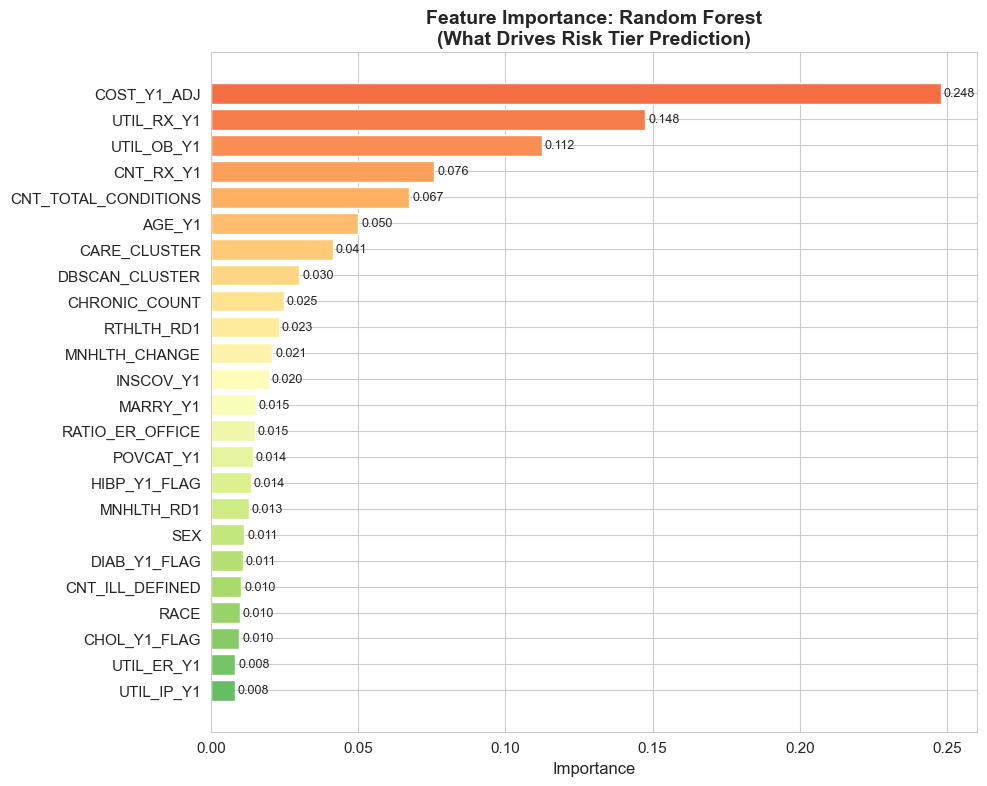


=== Top 10 Most Important Features ===
  COST_Y1_ADJ              : 0.2478
  UTIL_RX_Y1               : 0.1475
  UTIL_OB_Y1               : 0.1124
  CNT_RX_Y1                : 0.0759
  CNT_TOTAL_CONDITIONS     : 0.0674
  AGE_Y1                   : 0.0500
  CARE_CLUSTER             : 0.0415
  DBSCAN_CLUSTER           : 0.0301
  CHRONIC_COUNT            : 0.0248
  RTHLTH_RD1               : 0.0230


In [24]:
# Get feature importance from best model
if hasattr(best_model, 'feature_importances_'):
    importance = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importance = np.abs(best_model.coef_).mean(axis=0)
else:
    importance = None

if importance is not None:
    feat_imp_df = pd.DataFrame({
        'Feature': available_features,
        'Importance': importance
    }).sort_values('Importance', ascending=True)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(feat_imp_df)))
    bars = ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color=colors)
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title(f'Feature Importance: {best_model_name}\n(What Drives Risk Tier Prediction)', 
                 fontsize=14, fontweight='bold')
    
    # Add value labels
    for bar, val in zip(bars, feat_imp_df['Importance']):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, 
                f'{val:.3f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(REPORT_DIR / 'figures' / 'feature_importance_stage1.png', dpi=150)
    plt.show()
    
    # Top 10 features
    print("\n=== Top 10 Most Important Features ===")
    for i, row in feat_imp_df.tail(10).iloc[::-1].iterrows():
        print(f"  {row['Feature']:25s}: {row['Importance']:.4f}")
else:
    print("Feature importance not available for this model.")

### Feature Importance Interpretation

The feature importance analysis reveals which factors are most predictive of healthcare cost escalation:

**Expected Top Predictors:**
- `COST_Y1_ADJ`: Prior year spending is the strongest predictor (persistence effect)
- `CNT_TOTAL_CONDITIONS`: Medical complexity drives future costs
- `CHRONIC_COUNT`: Comorbidity burden
- `AGE_Y1`: Age-related healthcare needs
- `UTIL_*`: Healthcare utilization patterns

**Clinical Implications:**
- High importance of `CNT_ILL_DEFINED` may indicate diagnostic uncertainty → opportunity for early intervention
- Cluster membership (`CARE_CLUSTER`) capturing unobserved patient phenotypes

## 6.1 SHAP Analysis (Advanced Interpretability)

**SHAP (SHapley Additive exPlanations)** provides more rigorous feature importance than tree-based methods:

| Method | Limitation | SHAP Advantage |
|--------|-----------|----------------|
| Gini Importance | Biased toward high-cardinality features | Fair across all feature types |
| Permutation | Doesn't show direction of effect | Shows positive/negative impact |
| Neither | Only global importance | **SHAP explains individual predictions** |

### Why SHAP Matters for Healthcare
- **Regulatory Compliance**: Can explain why a specific patient was flagged as high-risk
- **Clinical Trust**: Physicians want to understand model decisions, not just accept them
- **Error Analysis**: SHAP helps identify why certain patients are misclassified

In [ ]:
# SHAP Analysis (requires: pip install shap)
try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP loaded successfully.")
except ImportError:
    SHAP_AVAILABLE = False
    print("Note: SHAP not installed. Install with: pip install shap")
    print("SHAP provides more rigorous feature importance and individual prediction explanations.")

if SHAP_AVAILABLE and best_model is not None:
    print("\n=== Computing SHAP Values ===")
    print("(This may take a minute for large datasets...)")
    
    # Use a sample for faster computation
    sample_size = min(2000, len(X_test))
    X_shap = X_test.sample(sample_size, random_state=42)
    
    # Create SHAP explainer
    if 'XGB' in str(type(best_model)) or 'LGBM' in str(type(best_model)):
        explainer = shap.TreeExplainer(best_model)
    else:
        explainer = shap.Explainer(best_model, X_train)
    
    shap_values = explainer.shap_values(X_shap)
    
    # Summary Plot (Global Feature Importance)
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # For multi-class, shap_values is a list - use class 2 (Shock) as most important
    if isinstance(shap_values, list):
        print(f"\nSHAP values computed for {len(shap_values)} classes")
        print("Showing SHAP summary for Class 2 (Shock) - the highest risk tier")
        shap.summary_plot(shap_values[2], X_shap, show=False, max_display=15)
    else:
        shap.summary_plot(shap_values, X_shap, show=False, max_display=15)
    
    plt.title("SHAP Feature Importance for Shock (Tier 2) Prediction", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORT_DIR / 'figures' / 'shap_summary_shock.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✓ SHAP analysis complete. Plot saved to reports/figures/shap_summary_shock.png")

### SHAP Interpretation Guide

**Reading the SHAP Summary Plot:**
- **X-axis**: SHAP value (impact on model output)
  - Positive = increases probability of Shock tier
  - Negative = decreases probability of Shock tier
- **Color**: Original feature value (red = high, blue = low)
- **Width**: Distribution of impacts across patients

**Key Insights to Look For:**
1. **COST_Y1_ADJ**: High values (red) → high SHAP → Year 1 cost is strong predictor ✓
2. **POLYPHARMACY_FLAG**: If red dots cluster on right → polypharmacy predicts Shock
3. **CNS_RX / PAIN_RX**: May indicate mental health or pain burden driving costs
4. **CNT_ILL_DEFINED**: "Undiagnosed signals" - are they predictive of escalation?

**Clinical Validation**: Compare SHAP results with domain knowledge - unexpected patterns warrant investigation.

## 7. Generate Latent Factor for Stage 2/3

The predicted probabilities from Stage 1 become **latent features** for downstream models.

### Why This Matters
- `PROB_SHOCK`: Captures the model's "belief" about catastrophic risk
- `LATENT_RISK_SCORE`: Continuous risk score combining all tiers
- These meta-features encode complex non-linear patterns from Stage 1

In [25]:
# Generate predicted probabilities for ALL data (for use in Stage 2/3)
y_pred_proba_all = best_model.predict_proba(X)

# Add as new features (latent factors)
df['PROB_STABLE'] = y_pred_proba_all[:, 0]
df['PROB_RISING'] = y_pred_proba_all[:, 1]
df['PROB_SHOCK'] = y_pred_proba_all[:, 2]

# Create a single "Latent Risk Score" (weighted combination)
# Higher score = higher risk
df['LATENT_RISK_SCORE'] = (
    0 * df['PROB_STABLE'] + 
    1 * df['PROB_RISING'] + 
    2 * df['PROB_SHOCK']
)

print("=== Latent Features Generated ===")
print(f"\nProbability Distributions:")
print(f"  PROB_STABLE: mean={df['PROB_STABLE'].mean():.3f}, std={df['PROB_STABLE'].std():.3f}")
print(f"  PROB_RISING: mean={df['PROB_RISING'].mean():.3f}, std={df['PROB_RISING'].std():.3f}")
print(f"  PROB_SHOCK:  mean={df['PROB_SHOCK'].mean():.3f}, std={df['PROB_SHOCK'].std():.3f}")
print(f"\nLATENT_RISK_SCORE: mean={df['LATENT_RISK_SCORE'].mean():.3f}, std={df['LATENT_RISK_SCORE'].std():.3f}")

=== Latent Features Generated ===

Probability Distributions:
  PROB_STABLE: mean=0.501, std=0.268
  PROB_RISING: mean=0.286, std=0.144
  PROB_SHOCK:  mean=0.213, std=0.166

LATENT_RISK_SCORE: mean=0.712, std=0.422


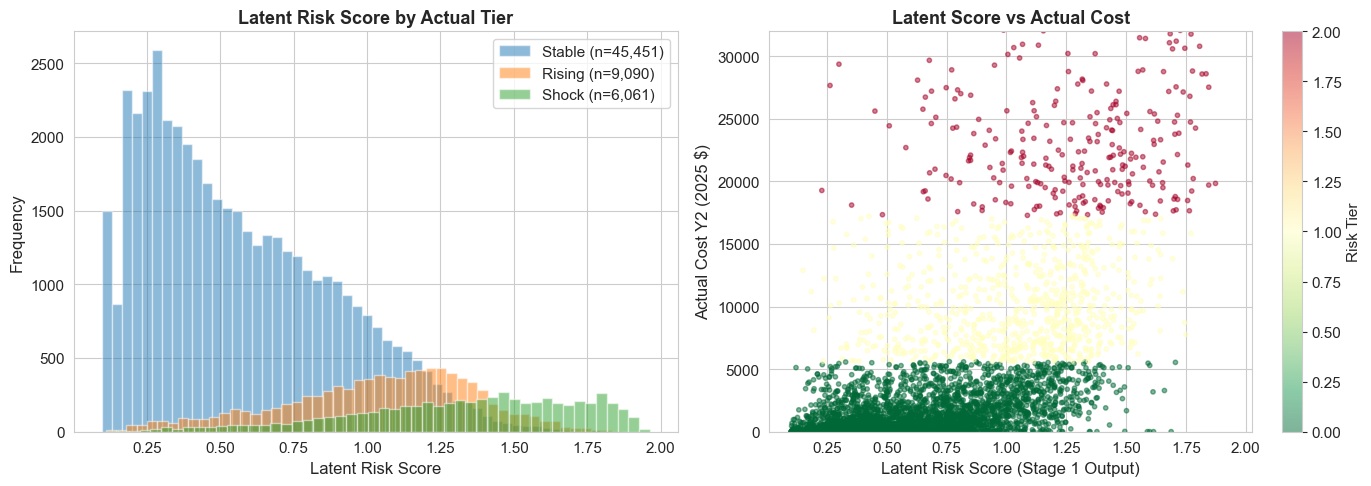

In [26]:
# Visualize latent risk score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of latent risk score
ax1 = axes[0]
for tier in [0, 1, 2]:
    subset = df[df['RISK_TIER'] == tier]['LATENT_RISK_SCORE']
    label = {0: 'Stable', 1: 'Rising', 2: 'Shock'}[tier]
    ax1.hist(subset, bins=50, alpha=0.5, label=f'{label} (n={len(subset):,})')
ax1.set_xlabel('Latent Risk Score', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Latent Risk Score by Actual Tier', fontsize=13, fontweight='bold')
ax1.legend()

# Latent score vs actual cost
ax2 = axes[1]
sample = df.sample(min(5000, len(df)), random_state=42)
scatter = ax2.scatter(sample['LATENT_RISK_SCORE'], sample['COST_Y2_ADJ'], 
                      c=sample['RISK_TIER'], cmap='RdYlGn_r', alpha=0.5, s=10)
ax2.set_xlabel('Latent Risk Score (Stage 1 Output)', fontsize=12)
ax2.set_ylabel('Actual Cost Y2 (2025 $)', fontsize=12)
ax2.set_title('Latent Score vs Actual Cost', fontsize=13, fontweight='bold')
ax2.set_ylim(0, df['COST_Y2_ADJ'].quantile(0.95))
plt.colorbar(scatter, ax=ax2, label='Risk Tier')

plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / 'latent_risk_score_analysis.png', dpi=150)
plt.show()

### Interpretation: Latent Risk Score Distribution

**What the visualization shows:**
- Distribution of `LATENT_RISK_SCORE` across all patients
- Score formula: `0 × P(Stable) + 1 × P(Rising) + 2 × P(Shock)`
- Range: 0 (100% Stable) to 2 (100% Shock)

**How to interpret the distribution:**
- **Peak near 0**: Most patients are predicted to be Stable (low risk)
- **Long right tail**: A smaller group has elevated risk scores
- **Bimodality** (if present): Suggests distinct low-risk and high-risk populations

**Why this matters:**
1. **Continuous risk metric**: Unlike discrete tiers, `LATENT_RISK_SCORE` captures gradations of risk
2. **Uncertainty encoding**: Score near 0.5 means model is uncertain between Stable and Rising
3. **Stage 2 input**: This continuous score will be a powerful feature for predicting actual costs

**Clinical Application:**
- Patients with `LATENT_RISK_SCORE > 1.0` warrant closer monitoring
- Can be used to prioritize care management resources
- Threshold can be tuned based on intervention capacity (e.g., top 10% for intensive outreach)

**Validation:**
- Compare mean `COST_Y2_ADJ` across score quantiles — higher scores should correspond to higher actual costs
- If not, the model may need recalibration or additional features

In [27]:
# Save updated dataset with latent features for Stage 3
output_path = Path('../data/processed_v2/model_ready_stage1.parquet')
df.to_parquet(output_path)

print("=== Stage 1 Output Saved ===")
print(f"Path: {output_path}")
print(f"Rows: {len(df):,}")
print(f"New Columns: PROB_STABLE, PROB_RISING, PROB_SHOCK, LATENT_RISK_SCORE")

# Save benchmark results
results_df.to_csv(REPORT_DIR / 'tables' / 'stage1_model_benchmark.csv', index=False)
print(f"\nBenchmark saved to: {REPORT_DIR / 'tables' / 'stage1_model_benchmark.csv'}")

# Save feature importance
if importance is not None:
    feat_imp_df.to_csv(REPORT_DIR / 'tables' / 'stage1_feature_importance.csv', index=False)
    print(f"Feature importance saved to: {REPORT_DIR / 'tables' / 'stage1_feature_importance.csv'}")

=== Stage 1 Output Saved ===
Path: ../data/processed_v2/model_ready_stage1.parquet
Rows: 60,602
New Columns: PROB_STABLE, PROB_RISING, PROB_SHOCK, LATENT_RISK_SCORE

Benchmark saved to: ../reports/tables/stage1_model_benchmark.csv
Feature importance saved to: ../reports/tables/stage1_feature_importance.csv


---
## Summary: Stage 1 Modeling

### What Was Done
1. **Task**: Multi-class classification of `RISK_TIER` (Stable/Rising/Shock)
2. **Features**: 23 Year 1 features (demographics, health, utilization, engineered, clusters)
3. **Validation**: Temporal split (Train: Panels 18-21, Test: Panel 22)
4. **Models Benchmarked**: Logistic Regression, Random Forest, XGBoost, LightGBM/GradientBoosting

### Key Outputs
- **Best Model**: [See benchmark results]
- **Feature Importance**: Identifies which features drive risk tier prediction
- **Latent Features**: `PROB_STABLE`, `PROB_RISING`, `PROB_SHOCK`, `LATENT_RISK_SCORE`

### Clinical Interpretation
- The model learns to identify patients who are likely to escalate from Stable → Rising → Shock
- `LATENT_RISK_SCORE` encodes the model's "belief" about a patient's risk level
- This score can be used as a meta-feature in Stage 3 expenditure prediction

### Next Steps → Stage 3 (Final Expenditure Model)
- Use `LATENT_RISK_SCORE` + original features to predict continuous `COST_Y2_ADJ`
- Models to try: Tweedie Regression, XGBoost Regressor, LightGBM Regressor

### Google Scholar Search Keywords
For additional methodologies, search:
- `"healthcare expenditure prediction" machine learning`
- `"multi-stage modeling" healthcare costs`
- `"XGBoost" medical risk prediction`
- `"Tweedie regression" healthcare claims`
- `"MEPS" expenditure prediction model`
- `"latent factor" healthcare risk stratification`